# wormsim2 — Project Tour

A version-by-version walkthrough of what each milestone adds, with a runnable
**input → output** example for each one.

The channel kinetics and ODE integrator cells are **reference Python implementations**
that mirror the C++ code exactly (same formulas, same catalog parameters) — they can be
run without a C++ build and serve as a sanity check on the numerics.

| Version | Date | What landed |
|---|---|---|
| v0.1.0 | 2026-06-15 | Scientific charter, requirements, architecture, issue tracker |
| v0.2.0 | 2026-06-15 | Dual-format network loader (`io/`): NeuroML2 + NEURON NMODL |
| v0.3.0 | 2026-06-15 | GitHub Actions CI + 66-check C++ quality checker |
| v0.4.0 | 2026-06-15 | HH ODE integrator over 302-neuron connectome (`neural/`) |

**Requirements:** `numpy`, `matplotlib` (both standard; no GPU or C++ build needed)

In [1]:
import sys, subprocess, pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

REPO_ROOT = pathlib.Path('..').resolve()   # notebooks/ is one level below project root
print('Project root:', REPO_ROOT)

Project root: /Users/vghayoomie/git/wormsim2


---

## v0.1.0 — Scientific Foundation

**What was added:**
- `docs/research/00-motivation-objectives-related-work.md` — scientific charter: motivation,
  related-work survey (Sibernetic / MetaWorm / BAAIWorm / ElegansBot), gap analysis, four-layer
  architecture, three-level validation strategy, objectives G1–G7 + E1–E6.
- `docs/requirements/01-requirements-analysis.md` — stakeholders, domain assumptions (DA1–DA5),
  functional requirements (FR-SIM/COMPUTE/OUT/VALID/DEPLOY), non-functional requirements,
  five use cases.
- `docs/design/02-architecture-design.md` — multi-view architecture (C&C / Module / Deployment),
  14 components, 10 verification gates (VR-01–VR-10).
- `docs/ISSUES.md`, `README.md`, `CHANGELOG.md`, `VERSION`, `LICENSE`.

**No executable module at this milestone** — this version establishes the scientific and
engineering foundations that all subsequent code targets.

In [2]:
# v0.1.0: What the project targets (from docs/research/00-...)

print('Target architecture (four-layer GPU-first closed loop):')
print()
arch = """
(1) Neural layer       GPU-batched Hodgkin-Huxley over the connectome
        |              302 neurons x synapses + gap junctions
        v
(2) Neuromuscular map  motoneuron V -> 95 body-wall-muscle activations
        v
(3) Body mechanics     corotated linear-elastic FEM (per-quadrant muscle drive)
        v
(4) Environment        agar (crawl) <-> liquid (swim) . contact + drag
        ^                                              |
        +--- (5) Proprioceptive feedback: curvature ---+
                  -> stretch-receptor channels -> motor circuit
        |
        v
(6) Output layer       WCON export + browser 3D viewer
"""
print(arch)

goals = [
    ('G1', 'Real-time on commodity GPU while retaining HH ion channels'),
    ('G2', 'Corotated linear-elastic FEM body (crawl / swim / omega-turn)'),
    ('G3', 'Closed proprioceptive loop — stretch feedback sustains undulation'),
    ('G4', '256-feature WCON behavioural validation'),
    ('G5', 'Ion-channel perturbation -> predicted phenotype'),
    ('G6', 'Open, reproducible, tested, containerised, HPC-deployable'),
    ('G7', 'Web-friendly output + self-contained browser 3D viewer'),
]
print('Objectives:')
for tag, desc in goals:
    print(f'  [{tag}] {desc}')

Target architecture (four-layer GPU-first closed loop):


(1) Neural layer       GPU-batched Hodgkin-Huxley over the connectome
        |              302 neurons x synapses + gap junctions
        v
(2) Neuromuscular map  motoneuron V -> 95 body-wall-muscle activations
        v
(3) Body mechanics     corotated linear-elastic FEM (per-quadrant muscle drive)
        v
(4) Environment        agar (crawl) <-> liquid (swim) . contact + drag
        ^                                              |
        +--- (5) Proprioceptive feedback: curvature ---+
                  -> stretch-receptor channels -> motor circuit
        |
        v
(6) Output layer       WCON export + browser 3D viewer

Objectives:
  [G1] Real-time on commodity GPU while retaining HH ion channels
  [G2] Corotated linear-elastic FEM body (crawl / swim / omega-turn)
  [G3] Closed proprioceptive loop — stretch feedback sustains undulation
  [G4] 256-feature WCON behavioural validation
  [G5] Ion-channel perturbation -> pr

---

## v0.2.0 — Network Loading: Dual-Format IO Module

**What was added:** `src/cpp/io/` — the `worksim2_io` static library implements FR-NET-01/02/03:

| Class | Role |
|---|---|
| `NetworkConfig` | In-memory biophysics + topology (neurons, channels, gap junctions, synapses, NMJs) |
| `NEURONLoader` | Parse NMODL `.mod` blocks → `ChannelDef` + `NetworkConfig` |
| `NeuroMLLoader` | Parse NeuroML2 `.nml` XML → `NetworkConfig` |
| `NetworkInputParser` | Auto-detect format from extension; dispatch; apply perturbation spec |
| `PerturbationConfig` | Key=value spec file: scale conductances, override `v_initial_mV` |

**Input:** a NeuroML2 `.nml` file (or NEURON `.hoc`/`.mod` directory)  
**Output:** a `NetworkConfig` containing all neurons, channels, connectivity, NMJs

In [3]:
# v0.2.0: Python mirror of the C++ NetworkConfig structs
# (reference — no C++ build needed; shows the data model produced by NetworkInputParser::load)

from dataclasses import dataclass, field
from typing import List, Optional

@dataclass
class ChannelAssignment:
    channel_id: str
    conductance_density: float  # treated as effective whole-cell nS in NeuralIntegrator

@dataclass
class GapJunctionDef:
    neuron_a: int
    neuron_b: int
    conductance_nS: float = 0.1

@dataclass
class ChemSynapseDef:
    pre_neuron_id: int
    post_neuron_id: int
    conductance_nS: float
    e_rev_mV: float
    tau_decay_ms: float = 10.0

@dataclass
class NMJDef:
    motor_neuron_id: int
    muscle_id: int        # 0..94  (95 body-wall muscles)
    weight: float = 1.0

@dataclass
class NeuronDef:
    id: int
    name: str
    capacitance_nF: float = 10.0   # treated as pF in NeuralIntegrator
    v_initial_mV: float = -65.0
    channels: List[ChannelAssignment] = field(default_factory=list)

@dataclass
class NetworkConfig:
    source_format: str = ''
    neurons: List[NeuronDef] = field(default_factory=list)
    gap_junctions: List[GapJunctionDef] = field(default_factory=list)
    chem_synapses: List[ChemSynapseDef] = field(default_factory=list)
    nmj_connections: List[NMJDef] = field(default_factory=list)

    def neuron_count(self): return len(self.neurons)
    def gap_junction_count(self): return len(self.gap_junctions)
    def find_neuron(self, name: str) -> Optional[NeuronDef]:
        return next((n for n in self.neurons if n.name == name), None)


# --- Input: mimics a minimal NeuroML2 file (3 neurons from the c302 connectome) ------
input_snippet = """
<!-- c302_A.nml (excerpt) -->
<population id="AVBL" component="GenericNeuronCell" size="1"/>
<population id="AVBR" component="GenericNeuronCell" size="1"/>
<population id="DB1"  component="GenericNeuronCell" size="1"/>
<electricalProjection ..> <!-- AVBL <-> AVBR gap junction, conductance 0.5 nS --> </..>
<electricalProjection ..> <!-- AVBR <-> DB1  gap junction, conductance 0.3 nS --> </..>
<continuousProjection ..> <!-- AVBL -> DB1   chem synapse, gmax 1.0 nS         --> </..>
"""
print('Input: NeuroML2 .nml file (excerpt)')
print(input_snippet)

# --- Output: NetworkConfig produced by NeuroMLLoader::load() ----------------------
cfg = NetworkConfig(
    source_format='NeuroML2',
    neurons=[
        NeuronDef(0, 'AVBL', channels=[ChannelAssignment('NCA', 0.8)]),
        NeuronDef(1, 'AVBR', channels=[ChannelAssignment('NCA', 0.8),
                                        ChannelAssignment('KD',  5.0)]),
        NeuronDef(2, 'DB1',  channels=[ChannelAssignment('KD',  5.0)]),
    ],
    gap_junctions=[
        GapJunctionDef(0, 1, conductance_nS=0.5),
        GapJunctionDef(1, 2, conductance_nS=0.3),
    ],
    chem_synapses=[
        ChemSynapseDef(0, 2, conductance_nS=1.0, e_rev_mV=0.0),
    ],
    nmj_connections=[
        NMJDef(motor_neuron_id=2, muscle_id=7),
    ]
)

print('Output: NetworkConfig')
print(f'  neuron_count()       = {cfg.neuron_count()}')
print(f'  gap_junction_count() = {cfg.gap_junction_count()}')
print(f'  find_neuron("AVBL")  = {cfg.find_neuron("AVBL")}')
print()
for n in cfg.neurons:
    chs = ', '.join(f'{c.channel_id}({c.conductance_density} nS)' for c in n.channels)
    print(f'  [{n.id}] {n.name:<8}  C={n.capacitance_nF} pF  V0={n.v_initial_mV} mV  channels: {chs}')
print()
for gj in cfg.gap_junctions:
    na = cfg.neurons[gj.neuron_a].name
    nb = cfg.neurons[gj.neuron_b].name
    print(f'  GJ: {na} <-> {nb}  {gj.conductance_nS} nS')
for s in cfg.chem_synapses:
    pre = cfg.neurons[s.pre_neuron_id].name
    post = cfg.neurons[s.post_neuron_id].name
    print(f'  SYN: {pre} -> {post}  {s.conductance_nS} nS  E_rev={s.e_rev_mV} mV')
for m in cfg.nmj_connections:
    mn = cfg.neurons[m.motor_neuron_id].name
    print(f'  NMJ: {mn} -> muscle #{m.muscle_id}  weight={m.weight}  (95 BWM total)')

Input: NeuroML2 .nml file (excerpt)

<!-- c302_A.nml (excerpt) -->
<population id="AVBL" component="GenericNeuronCell" size="1"/>
<population id="AVBR" component="GenericNeuronCell" size="1"/>
<population id="DB1"  component="GenericNeuronCell" size="1"/>
<electricalProjection ..> <!-- AVBL <-> AVBR gap junction, conductance 0.5 nS --> </..>
<electricalProjection ..> <!-- AVBR <-> DB1  gap junction, conductance 0.3 nS --> </..>
<continuousProjection ..> <!-- AVBL -> DB1   chem synapse, gmax 1.0 nS         --> </..>

Output: NetworkConfig
  neuron_count()       = 3
  gap_junction_count() = 2
  find_neuron("AVBL")  = NeuronDef(id=0, name='AVBL', capacitance_nF=10.0, v_initial_mV=-65.0, channels=[ChannelAssignment(channel_id='NCA', conductance_density=0.8)])

  [0] AVBL      C=10.0 pF  V0=-65.0 mV  channels: NCA(0.8 nS)
  [1] AVBR      C=10.0 pF  V0=-65.0 mV  channels: NCA(0.8 nS), KD(5.0 nS)
  [2] DB1       C=10.0 pF  V0=-65.0 mV  channels: KD(5.0 nS)

  GJ: AVBL <-> AVBR  0.5 nS
  GJ: A

---

## v0.3.0 — CI Pipeline & C++ Quality Checker

**What was added:**
- `.github/workflows/ci-baseline.yml` — cmake build, CTest (all labels), cppcheck, clang-tidy,
  lcov coverage, artifact upload.
- `.github/workflows/auto-release.yml` — fires on `v*` tag push; creates GitHub Release from CHANGELOG.
- `.github/workflows/backfill-releases.yml` — manual workflow to backfill releases for existing tags.
- `src/cpp/tests/static/cpp_quality_checker.py` — 66 automated checks in 12 categories
  (TC/FP/NS/FN/RA/CL/TM/SL/LB/PS/OL/DS); runs as CTest target `cpp_quality`; exit-1 on regression.

**Input:** the entire C++ source tree (`src/cpp/`, `CMakeLists.txt`, `docker/`)  
**Output:** `N/66 checks passed` — fails CI if any check regresses

In [4]:
# v0.3.0: Run the quality checker against the live source tree
checker = REPO_ROOT / 'src/cpp/tests/static/cpp_quality_checker.py'
result = subprocess.run(
    [sys.executable, str(checker), str(REPO_ROOT)],
    capture_output=True, text=True
)

print('Input:  C++ source tree at', REPO_ROOT)
print('Output:')
# Print last 30 lines (summary) and first hint of a failure if any
lines = (result.stdout + result.stderr).strip().splitlines()
for ln in lines[-30:]:
    print(' ', ln)
print(f'\nExit code: {result.returncode}  ({'PASS' if result.returncode == 0 else 'FAIL'})')

Input:  C++ source tree at /Users/vghayoomie/git/wormsim2
Output:
  PASS  [TM-02] NetworkConfig.h — 6 distinct vector<T> instantiations: {'ChemSynapseDef', 'GateVar', 'NMJDef', 'NeuronDef', 'ChannelAssignment', 'GapJunctionDef'}
  PASS  [TM-03] NetworkInputParser.h / NetworkConfig.h — std::optional<T> used
  PASS  [TM-04] NEURONLoader.cpp:103 — std::sregex_iterator (regex forward iterator)
  PASS  [TM-05] NeuroMLLoader.cpp:80 — std::sregex_iterator in NeuroML XML scanner
  PASS  [TM-06] NEURONLoader.cpp:202 — [[maybe_unused]] attribute on stub parameter
  PASS  [SL-01] NEURONLoader.cpp:29 — std::transform for toLower (algorithm over range)
  PASS  [SL-02] NEURONLoader.cpp:189 — std::filesystem::directory_iterator for .mod scan
  PASS  [SL-03] PerturbationConfig.cpp:41/83/92 — string_view::starts_with (C++20)
  PASS  [SL-04] NEURONLoader.cpp:171 — istreambuf_iterator<char> whole-file read
  PASS  [SL-05] PerturbationConfig.cpp — std::getline line-by-line parsing
  PASS  [SL-06] NEURONLo

---

## v0.4.0 — NeuralIntegrator: HH ODE over the Full Connectome

**What was added:** `src/cpp/neural/` — the `wormsim2_neural` static library implements FR-SIM-01:

| File | Role |
|---|---|
| `ChannelKinetics.h/cpp` | Built-in c302 channel catalog (NCA/KD/KA/KQS/KVS/IR); Boltzmann + Gaussian-tau kinetics; pure `rush_larsen()` |
| `NeuralState.h/cpp` | SoA arrays: `v[n]`, `gate[n×stride]`, `s_syn[n_syn]`; GPU-friendly layout |
| `NeuralIntegrator.h/cpp` | Conductance-method step over full connectome; Rush–Larsen gate update; graded synapse gating |

**Key formulas (unit system: mV · ms · pA · pF)**

Gate steady-state (Boltzmann):
$$x_\infty(V) = \frac{1}{1+\exp\!\left(\frac{V_{1/2}-V}{k}\right)}$$

Gate time constant (Gaussian):
$$\tau_x(V) = \tau_0 + \tau_a\,\exp\!\left(-\left(\frac{V-\tau_V}{\tau_w}\right)^2\right)$$

Rush–Larsen gate update (exact exponential at constant $V$ over $\Delta t$):
$$x_{n+1} = x_\infty + (x_n - x_\infty)\,e^{-\Delta t/\tau_x}$$

Conductance method voltage update (implicit diagonal, backward Euler for $V$):
$$V_{n+1} = \frac{C_m V_n + \Delta t\,(I_\text{rhs} + I_\text{ext})}{C_m + \Delta t\,g_\text{total}},
\quad I_\text{rhs} = \sum_\text{ch} g_\text{ch}\,E_\text{rev} + \sum_\text{gj} g_\text{gj}\,V_\text{other}$$

> **Note:** $I_\text{rhs}$ uses $g\,E_\text{rev}$ and $g_\text{gj}\,V_\text{other}$ — *not* $g(E_\text{rev}-V)$ or $g(V_\text{other}-V)$.
> The $-V$ terms are already absorbed into the implicit denominator.
> Fixed point: $V^* = E_\text{rev}$ ✓ (verifiable: leak-only neuron at reversal is invariant).

**Input:** `NetworkConfig` (loaded by v0.2.0 IO module) + initial conditions + `dt`  
**Output:** voltage trace $V(t)$ for all 302 neurons

In [5]:
# v0.4.0: Build C++ neural tests inside the wormsim2-dev Docker image
# (mirrors the CI pipeline — cmake configure + incremental build)

def run_in_docker(cmd, repo_root=REPO_ROOT):
    """Run a bash command inside wormsim2-dev with the repo mounted at /wormsim2."""
    r = subprocess.run(
        ['docker', 'run', '--rm',
         '-v', f'{repo_root}:/wormsim2',
         '-w', '/wormsim2',
         'wormsim2-dev', 'bash', '-c', cmd],
        capture_output=True, text=True
    )
    return r.stdout.strip(), r.stderr.strip(), r.returncode

build_cmd = """
# Clear stale cache if it was built at a different mount path
if grep -q '/workspace' build/CMakeCache.txt 2>/dev/null; then
    rm -f build/CMakeCache.txt
fi
cmake -B build -S . -G Ninja -DCMAKE_BUILD_TYPE=RelWithDebInfo -Wno-dev > /dev/null 2>&1
cmake --build build --target test_hh_single test_gap_junction -j4 2>&1
"""
stdout, stderr, rc = run_in_docker(build_cmd)
print(f'Build: {"OK" if rc == 0 else f"FAILED (rc={rc})"}')
if rc != 0:
    print(stderr or stdout)

Build: OK


### `test_hh_single` — single-compartment HH (4 assertions)

| Test | What it verifies | Analytic reference |
|---|---|---|
| `test_leak_at_reversal` | `V(V₀=E_rev)` stays constant for 1000 steps | Fixed point of conductance method: $V^*=E_\text{rev}$ |
| `test_leak_decay` | NCA decay over 25 ms vs $E+(V_0-E)e^{-t/\tau}$, $\tau=C/g=12.5$ ms | Backward Euler exact for pure leak (no time-discretisation error) |
| `test_kd_gate_direction` | KD gate $n$ rises from 0.05 toward $n_\infty(-40)\approx0.11$ over 2 ms | $n_\infty(V)>n_0$ at $V=-40$ mV ⟹ gate must increase |
| `test_external_current` | 200 pA depolarising pulse raises $V$ | $I_\text{ext}>0$ ⟹ $V_\text{after}>V_\text{before}$ |

In [6]:
stdout, stderr, rc = run_in_docker('./build/src/cpp/tests/neural/test_hh_single')
print(stdout)
assert rc == 0, f'test_hh_single failed (rc={rc})\n{stderr}'

PASS  test_leak_at_reversal
PASS  test_leak_decay
PASS  test_kd_gate_direction
PASS  test_external_current

All HH single-neuron tests passed.


### `test_gap_junction` — two-neuron gap-junction coupling (3 assertions)

| Test | What it verifies | Analytic reference |
|---|---|---|
| `test_mean_conserved` | $(V_A+V_B)/2$ constant over 100 ms (no channels) | Gap current is antisymmetric ⟹ $d(V_A+V_B)/dt=0$ |
| `test_diff_decay` | $\|V_A-V_B\|$ matches $\|\Delta V_0\|e^{-2g/C\,t}$ at $t=25$ ms (2% tol) | Eigenmode of the implicit 2-neuron update matrix |
| `test_convergence` | $\|V_A-V_B\|<0.5$ mV after 500 ms $\gg \tau_\text{diff}=C/(2g)=5$ ms | Exponential decay to zero |

In [7]:
stdout, stderr, rc = run_in_docker('./build/src/cpp/tests/neural/test_gap_junction')
print(stdout)
assert rc == 0, f'test_gap_junction failed (rc={rc})\n{stderr}'

PASS  test_mean_conserved
PASS  test_diff_decay
PASS  test_convergence

All gap junction tests passed.


### Analytic reference curves

The plots below show the analytic solutions against which the C++ tests above assert.
They use only closed-form math — no numerical integrator is reimplemented here.

NCA: tau=12.5 ms  |  V(t→∞) → -20.0 mV
GJ:  tau_diff=5.0 ms  |  |ΔV| decays from 40 mV → 0


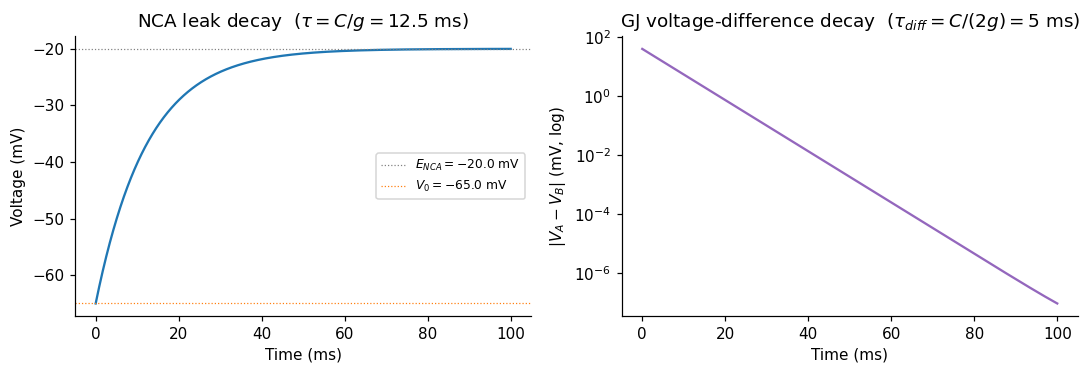

In [8]:
t = np.linspace(0, 100, 2000)

# NCA leak decay: V(t) = E + (V0-E)*exp(-g/C*t)  [verified by test_leak_decay]
C_m, g_NCA, E_NCA, V0 = 10.0, 0.8, -20.0, -65.0
tau_NCA = C_m / g_NCA   # 12.5 ms
v_nca = E_NCA + (V0 - E_NCA) * np.exp(-g_NCA / C_m * t)

# GJ V_diff decay: |ΔV(t)| = |ΔV0|*exp(-2g/C*t)  [verified by test_diff_decay]
g_gj, C_gj = 1.0, 10.0
dV0 = abs(-80.0 - (-40.0))
tau_diff = C_gj / (2 * g_gj)   # 5 ms
v_diff = dV0 * np.exp(-2 * g_gj / C_gj * t)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(t, v_nca, color='tab:blue')
axes[0].axhline(E_NCA, color='gray', ls=':', lw=0.8, label=f'$E_{{NCA}}={E_NCA}$ mV')
axes[0].axhline(V0, color='tab:orange', ls=':', lw=0.8, label=f'$V_0={V0}$ mV')
axes[0].set_xlabel('Time (ms)'); axes[0].set_ylabel('Voltage (mV)')
axes[0].set_title(f'NCA leak decay  ($\\tau = C/g = {tau_NCA:.1f}$ ms)')
axes[0].legend(fontsize=8)

axes[1].semilogy(t, v_diff + 1e-8, color='tab:purple')
axes[1].set_xlabel('Time (ms)'); axes[1].set_ylabel('$|V_A - V_B|$ (mV, log)')
axes[1].set_title(f'GJ voltage-difference decay  ($\\tau_{{diff}} = C/(2g) = {tau_diff:.0f}$ ms)')

plt.tight_layout()
print(f'NCA: tau={tau_NCA:.1f} ms  |  V(t→∞) → {E_NCA} mV')
print(f'GJ:  tau_diff={tau_diff:.1f} ms  |  |ΔV| decays from {dV0:.0f} mV → 0')